In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
customers = pd.read_csv("customers_analytics.csv")

loans = pd.read_csv("loans_clean.csv")

In [4]:
loans.head()

,LoanID,CustomerID,LoanType,Amount,InterestRate,EMI,Status,PreviousDefaults
0,L0000001,112024,Education Loan,5068600,7.96,61884,Default,0
1,L0000002,104191,Education Loan,12064952,7.95,79131,Active,1
2,L0000003,105240,Education Loan,8551719,11.65,12540,Active,0
3,L0000004,102463,Business Loan,5360673,8.72,30254,Active,1
4,L0000005,102037,Business Loan,3191428,13.17,215332,Active,0


In [5]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   LoanID            30000 non-null  object 
 1   CustomerID        30000 non-null  int64  
 2   LoanType          30000 non-null  object 
 3   Amount            30000 non-null  int64  
 4   InterestRate      30000 non-null  float64
 5   EMI               30000 non-null  int64  
 6   Status            30000 non-null  object 
 7   PreviousDefaults  30000 non-null  int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 1.8+ MB


In [6]:
loans.describe()

,CustomerID,Amount,InterestRate,EMI,PreviousDefaults
count,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000
mean,107473.893200,7.534173e+06,11.988943,125625.090667,0.245033
std,4323.155404,4.319709e+06,3.165301,71846.674083,0.626901
min,100001.000000,5.157300e+04,6.500000,1515.000000,0.000000
25%,103747.000000,3.827817e+06,9.260000,63478.000000,0.000000
50%,107456.000000,7.527286e+06,11.970000,125509.000000,0.000000
75%,111209.250000,1.126658e+07,14.720000,188177.750000,0.000000
max,115000.000000,1.499954e+07,17.500000,249997.000000,3.000000


In [7]:
loans['LoanType'].value_counts()

LoanType
Personal Loan     6028
Business Loan     6025
Education Loan    5999
Home Loan         5977
Car Loan          5971
Name: count, dtype: int64

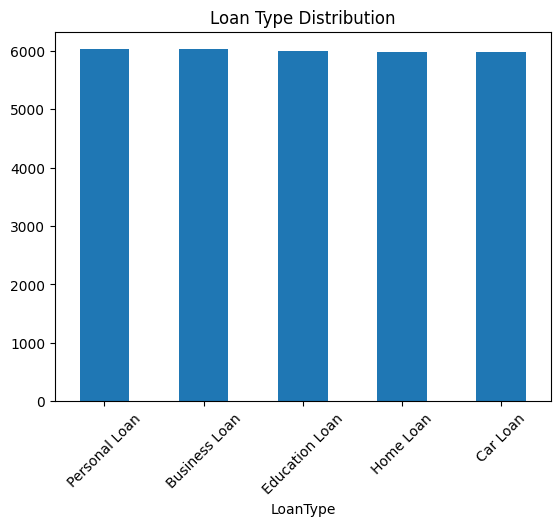

In [8]:
loans['LoanType'].value_counts().plot(kind='bar')

plt.title("Loan Type Distribution")

plt.xticks(rotation=45)

plt.show()

# Loan Status Distribution 

In [9]:
loans['Status'].value_counts()

Status
Active     20374
Closed      4791
Pending     2421
Default     2414
Name: count, dtype: int64

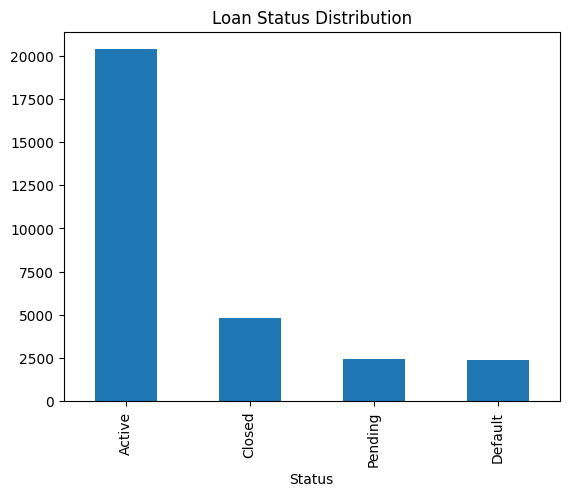

In [10]:
loans['Status'].value_counts().plot(kind='bar')

plt.title("Loan Status Distribution")

plt.show()

# NPA Percentage

In [11]:
npa=(loans['Status']=='Default').mean()*100

print("NPA Percentage :",round(npa,2),"%")

NPA Percentage : 8.05 %


# Average Loan by type

In [12]:
loans.groupby('LoanType')['Amount'].mean().sort_values(ascending=False)

LoanType
Personal Loan     7.610228e+06
Education Loan    7.556728e+06
Car Loan          7.537767e+06
Business Loan     7.490724e+06
Home Loan         7.475038e+06
Name: Amount, dtype: float64

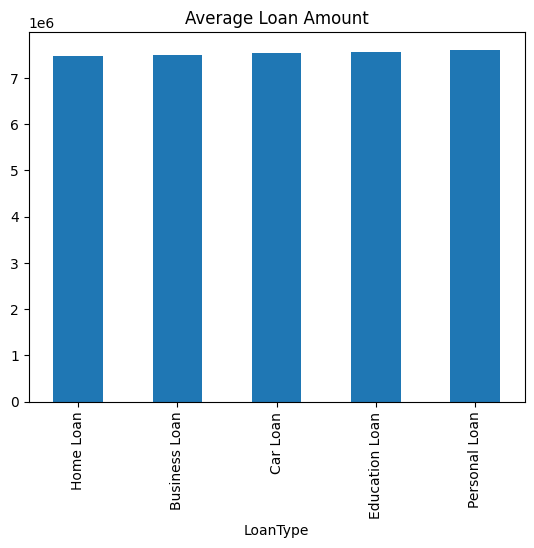

In [13]:
loans.groupby('LoanType')['Amount'].mean().sort_values().plot(kind='bar')
plt.title('Average Loan Amount')

plt.show()

# Emi distribution

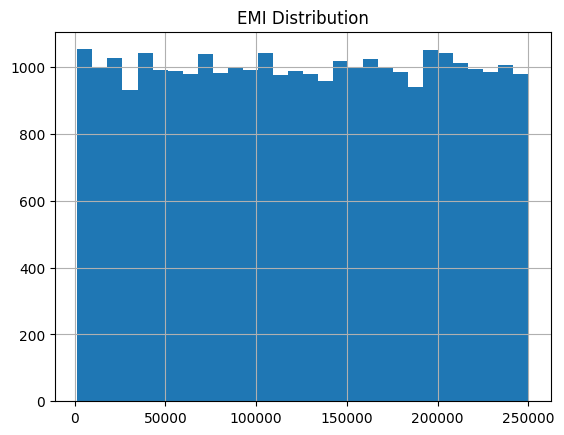

In [15]:
loans['EMI'].hist(bins=30)
plt.title('EMI Distribution')
plt.show()

# Previous Defaults

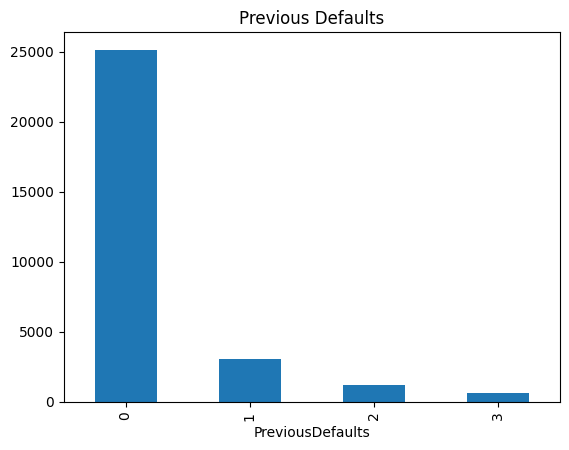

In [16]:
loans['PreviousDefaults'].value_counts().plot(kind='bar')
plt.title('Previous Defaults')

plt.show()

# Merge Customer and Loan Data

In [17]:
risk= customers.merge(loans,on='CustomerID')

# High Risk Customers

In [19]:
high_risk=risk[(risk['CreditScore']<600)
&
(risk['PreviousDefaults']>0)
&
(risk['Status']=='Default')
]

In [20]:
len(high_risk)

50

In [21]:
high_risk.head()

,CustomerID,Age,Gender,City,Occupation,AnnualSalary,CreditScore,AccountBalance,CustomerTenureYears,BranchID,SalarySegment,LoanID,LoanType,Amount,InterestRate,EMI,Status,PreviousDefaults
1405,100702,71,Male,Jaipur,Government,3013404,594,4550538,17,B018,High Income,L0013137,Business Loan,14053039,14.00,99198,Default,2
3523,101746,73,Female,Pune,Government,3884217,588,6635182,22,B047,High Income,L0015615,Business Loan,2221074,13.11,189401,Default,1
3590,101782,33,Male,Indore,Student,2982408,577,4501596,3,B011,High Income,L0019579,Education Loan,3325880,9.88,217965,Default,3
4748,102356,23,Female,Chennai,Business,3569657,584,2476787,28,B009,High Income,L0003965,Home Loan,9224936,15.78,222151,Default,3
5563,102778,26,Male,Delhi,Retired,1737463,515,2811548,17,B017,Upper Middle,L0029258,Education Loan,988938,7.70,64155,Default,1


# High Risk Customers by City

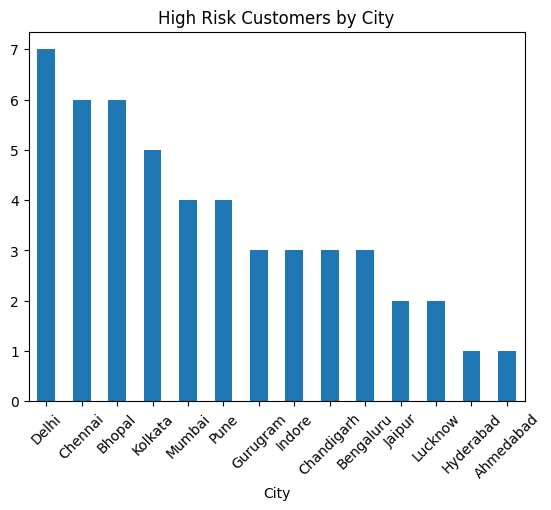

In [22]:
high_risk['City'].value_counts().plot(kind='bar')

plt.title('High Risk Customers by City')

plt.xticks(rotation=45)

plt.show()

# Credit Score Distribution

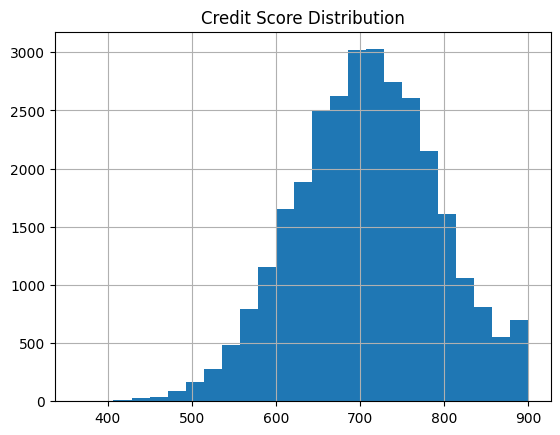

In [23]:
risk['CreditScore'].hist(bins=25)

plt.title('Credit Score Distribution')

plt.show()

# Default rate by Loan type 

In [25]:
pd.crosstab(loans['LoanType'],loans['Status'],normalize='index')*100

Status,Active,Closed,Default,Pending
LoanType,,,,
Business Loan,68.331950,15.435685,8.497925,7.734440
Car Loan,67.861330,16.044214,7.653659,8.440797
Education Loan,69.011502,15.185864,8.201367,7.601267
Home Loan,67.224360,16.864648,7.696169,8.214823
Personal Loan,67.136695,16.323822,8.178500,8.360982


# Top 10 Biggest Loans

In [26]:
loans.sort_values('Amount',ascending=False).head(10)

,LoanID,CustomerID,LoanType,Amount,InterestRate,EMI,Status,PreviousDefaults
9590,L0009591,100366,Home Loan,14999535,14.29,11794,Pending,0
20021,L0020022,113931,Business Loan,14999497,14.75,107325,Active,0
22151,L0022152,105958,Personal Loan,14999439,16.89,136580,Active,2
20421,L0020422,105629,Home Loan,14999218,15.72,247728,Closed,0
14604,L0014605,100381,Education Loan,14998106,9.30,199011,Active,0
21684,L0021685,102608,Car Loan,14997786,6.73,46284,Active,0
24014,L0024015,105392,Personal Loan,14996641,11.90,35464,Active,0
15088,L0015089,109041,Personal Loan,14996515,15.23,245759,Active,0
28682,L0028683,114863,Personal Loan,14996040,7.52,32627,Active,0
28792,L0028793,105926,Car Loan,14995901,16.36,205259,Closed,0


# Premium Customers with Loans

In [27]:
premium=risk[(risk['AnnualSalary']>2000000)
&
(risk['CreditScore']>750)
&
(risk['Status']=='Active')
]

In [28]:
len(premium)

3926

In [30]:
risk.to_csv("risk_analytics.csv",index=False)

Key Insights

Home Loans constitute the largest loan portfolio.

NPA percentage is around 8.05%.

Customers with low credit score and previous defaults are major risk contributors.

Certain cities contribute more to defaults.

Premium customers maintain strong credit health.